# **0. Setup**

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

orders = pd.read_csv('orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv('order_items.csv')
products = pd.read_csv('products.csv')
returns = pd.read_csv('returns.csv')
traffic = pd.read_csv('web_traffic.csv', parse_dates=['date'])
inventory = pd.read_csv('inventory.csv', parse_dates=['snapshot_date'])
sales = pd.read_csv('sales.csv', parse_dates=['Date'])

# merge transaction
df = order_items.merge(orders, on='order_id', how='left')
df = df.merge(products, on='product_id', how='left')

# promo
df['is_promo'] = (df['promo_id'].notna() | df['promo_id_2'].notna()).astype(int)

# return
returns['is_return'] = 1
df = df.merge(returns[['order_id','product_id','is_return']],
              on=['order_id','product_id'], how='left')
df['is_return'] = df['is_return'].fillna(0)

# daily aggregation
daily = df.groupby('order_date').agg({
    'order_id':'nunique',
    'quantity':'sum',
    'is_promo':'mean',
    'is_return':'mean'
}).reset_index()

daily.rename(columns={'order_id':'orders'}, inplace=True)

# merge traffic + sales
daily = daily.merge(traffic, left_on='order_date', right_on='date', how='left')
daily = daily.merge(sales, left_on='order_date', right_on='Date', how='left')

/tmp/ipykernel_1939/343225998.py:7: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv('order_items.csv')


# **1. Revenue vs Promotion**

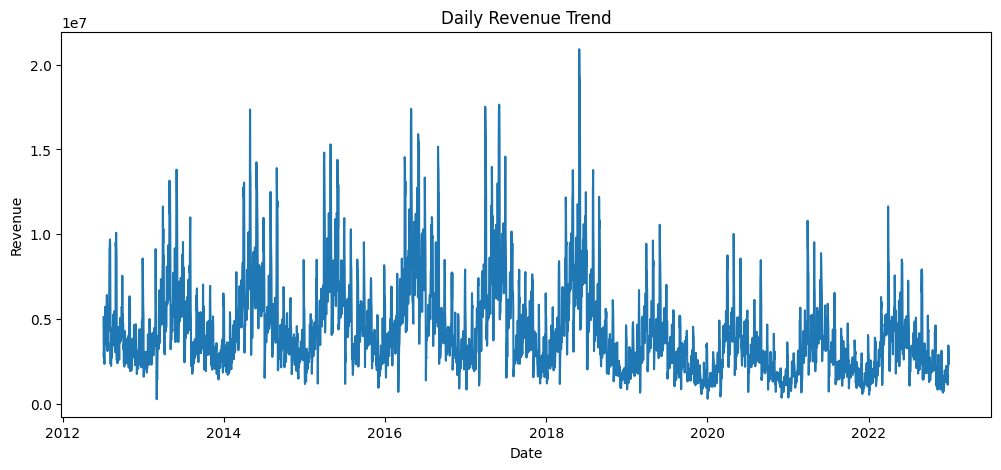

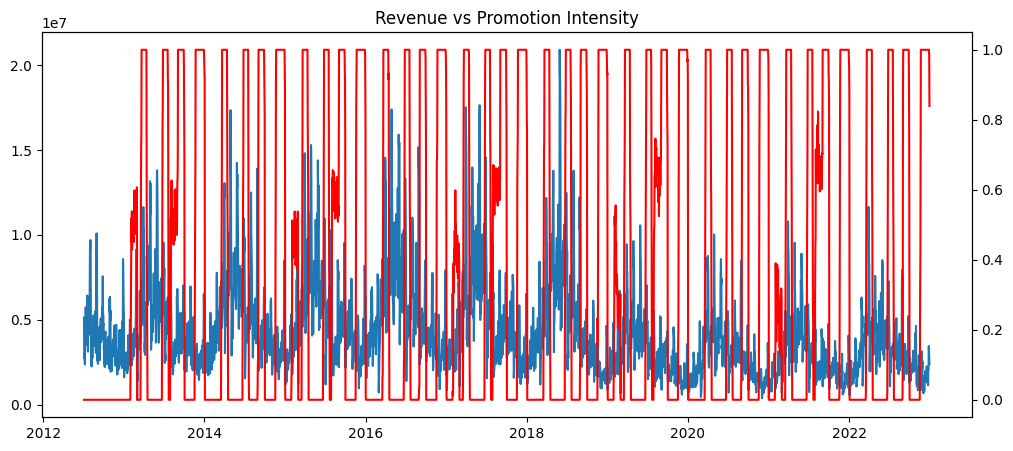

In [19]:
# Revenue theo thời gian
plt.figure(figsize=(12,5))
plt.plot(daily['order_date'], daily['Revenue'])
plt.title('Daily Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.show()

# Revenue vs Promotion intensity
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(daily['order_date'], daily['Revenue'], label='Revenue')
ax2 = ax1.twinx()
ax2.plot(daily['order_date'], daily['is_promo'], color='red', label='Promo Intensity')

plt.title('Revenue vs Promotion Intensity')
plt.show()

# **2. Return destroys Profit**

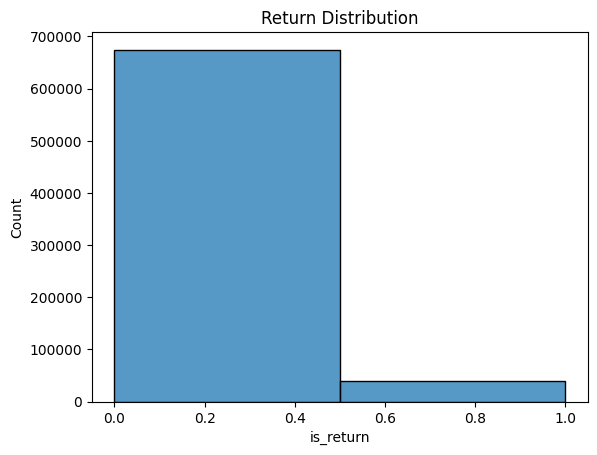

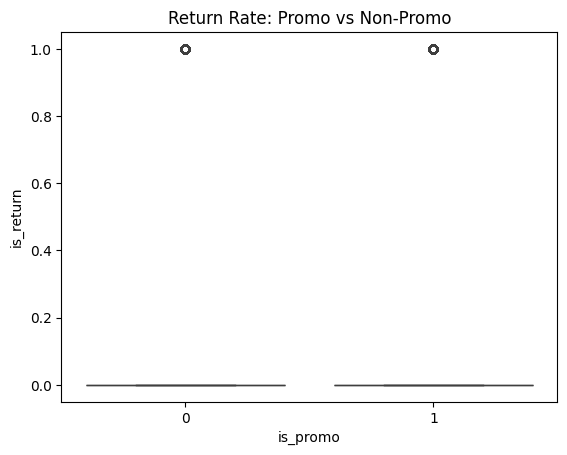

In [20]:
# Return rate distribution
sns.histplot(df['is_return'], bins=2)
plt.title('Return Distribution')
plt.show()

# Return vs Promotion
sns.boxplot(x='is_promo', y='is_return', data=df)
plt.title('Return Rate: Promo vs Non-Promo')
plt.show()

# **3. Traffic quality**

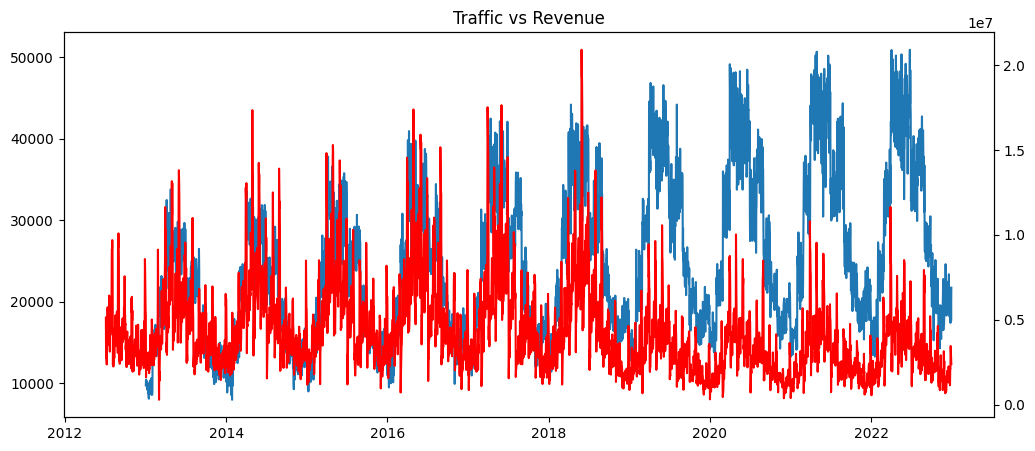

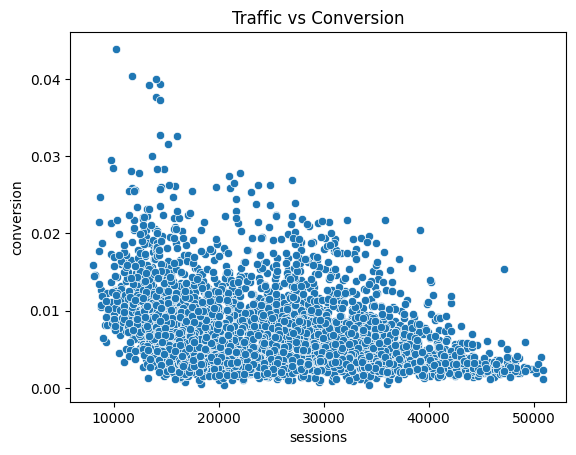

In [21]:
# Traffic vs Revenue
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(daily['order_date'], daily['sessions'], label='Traffic')
ax2 = ax1.twinx()
ax2.plot(daily['order_date'], daily['Revenue'], color='red')

plt.title('Traffic vs Revenue')
plt.show()

# Conversion proxy
daily['conversion'] = daily['orders'] / daily['sessions']

sns.scatterplot(x='sessions', y='conversion', data=daily)
plt.title('Traffic vs Conversion')
plt.show()

# **4. Inventory pressure**

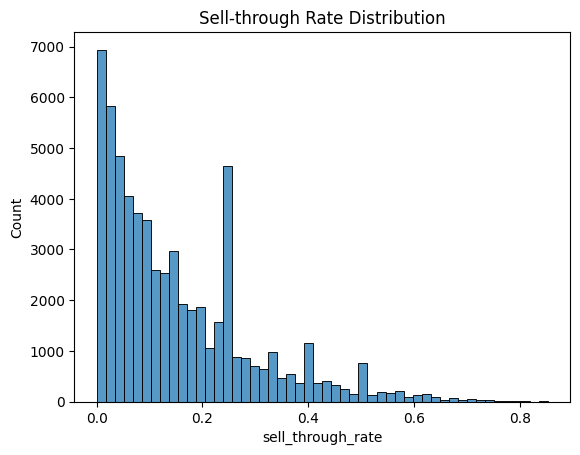

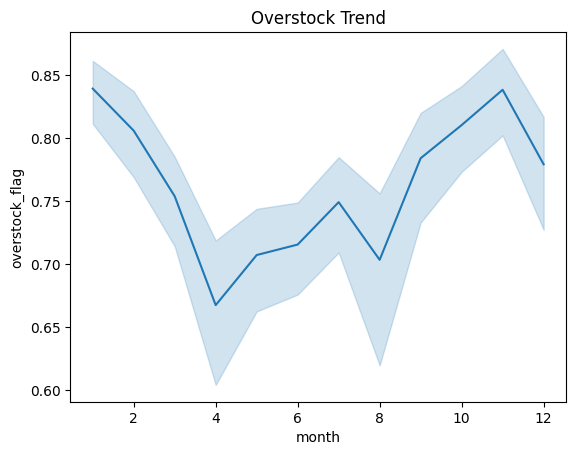

In [22]:
# Sell-through rate
sns.histplot(inventory['sell_through_rate'], bins=50)
plt.title('Sell-through Rate Distribution')
plt.show()

# Overstock vs Sales
inv_month = inventory.groupby(['year','month'])['overstock_flag'].mean().reset_index()

sns.lineplot(x='month', y='overstock_flag', data=inv_month)
plt.title('Overstock Trend')
plt.show()